# Audio Track Correlation Analysis
### Comparing an Original Song, its Karaoke Version, and a Different Song

**Objective (CO2):** Use correlation techniques to quantify how similar three
audio signals are to one another:

1. **Track A — Original song** (full mix, vocals + instruments)
2. **Track B — Karaoke version** (instrumental-only mix of the *same* song)
3. **Track C — A completely different song**

We expect:
- **A vs B** → high correlation (same melody/harmony/rhythm, missing vocals)
- **A vs C** and **B vs C** → low/near-zero correlation (unrelated musical content)

We measure similarity in two complementary ways:
- **Time-domain cross-correlation** on the raw waveform (captures overall
  signal alignment/timing similarity).
- **Feature-domain Pearson correlation** on MFCC and Chroma features
  (captures timbral and harmonic/melodic similarity, which is more musically
  meaningful than comparing raw samples).


## 1. Setup and Imports

In [1]:
# --- Core libraries ---
import numpy as np                      # numerical arrays and math
import librosa                           # audio loading + feature extraction
import librosa.display                   # convenient plotting helpers for audio
import scipy.signal                      # fast cross-correlation implementation
import matplotlib.pyplot as plt          # plotting
import seaborn as sns                    # nicer heatmaps
import pandas as pd                      # tabular summary of results

# Make plots a reasonable default size for readability
plt.rcParams["figure.figsize"] = (12, 4)

# Fixed sample rate used to load every track, so all signals are comparable
SR = 22050

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load the Audio Tracks

Replace the three file paths below with your own `.wav` / `.mp3` files:

```python
ORIGINAL_PATH = "original_song.mp3"
KARAOKE_PATH  = "karaoke_version.mp3"
DIFFERENT_PATH = "different_song.mp3"
```

If a file is not found (e.g. you are just running this notebook as a demo),
the loader below **automatically falls back to a synthetic demo signal** so
every cell still runs end-to-end and produces sensible output.


In [2]:
ORIGINAL_PATH = "original_song.wav"     # <-- put your original song's path here
KARAOKE_PATH = "karaoke_version.wav"    # <-- put your karaoke (instrumental) path here
DIFFERENT_PATH = "different_song.wav"   # <-- put an unrelated song's path here


def make_synthetic_track(kind, duration=10, sr=SR, seed=0):
    '''
    Build a small synthetic audio-like signal.

    This is ONLY used as a fallback when a real audio file can't be found,
    so the notebook remains runnable as a self-contained demo. It builds a
    4-note melody shared by 'original' and 'karaoke', with 'original' also
    carrying an extra vocal-like tone (so B is A minus the "vocals"), and a
    'different' track built from unrelated notes plus noise.
    '''
    rng = np.random.default_rng(seed)                       # reproducible randomness
    t = np.linspace(0, duration, int(sr * duration), endpoint=False)  # time axis

    melody_freqs = [220.0, 246.94, 277.18, 293.66]          # A3, B3, C#4, D4 (shared melody)
    melody = np.zeros_like(t)
    note_dur = duration / len(melody_freqs)
    for i, f in enumerate(melody_freqs):
        mask = (t >= i * note_dur) & (t < (i + 1) * note_dur)
        melody[mask] = 0.4 * np.sin(2 * np.pi * f * t[mask])  # one sine "note" per segment

    if kind == "original":
        # add a slow-vibrato "vocal" tone on top of the instrumental melody
        vocal = 0.35 * np.sin(2 * np.pi * 440 * t) * (0.5 + 0.5 * np.sin(2 * np.pi * 2 * t))
        signal = melody + vocal + 0.01 * rng.standard_normal(len(t))
    elif kind == "karaoke":
        # same melody, but WITHOUT the vocal tone -> mimics a karaoke instrumental track
        signal = melody + 0.01 * rng.standard_normal(len(t))
    else:  # "different"
        different_freqs = [110.0, 130.81, 146.83, 164.81]    # unrelated notes, one octave lower
        signal = np.zeros_like(t)
        for i, f in enumerate(different_freqs):
            mask = (t >= i * note_dur) & (t < (i + 1) * note_dur)
            signal[mask] = 0.4 * np.sin(2 * np.pi * f * t[mask]) + 0.2 * rng.standard_normal(mask.sum())

    return signal.astype(np.float32), sr


def load_track(path, kind, seed):
    '''
    Load an audio file with librosa. If the file is missing/unreadable,
    fall back to a synthetic demo track of the given 'kind' so the rest of
    the notebook still has something meaningful to analyze.
    '''
    try:
        y, sr = librosa.load(path, sr=SR, mono=True)   # downmix to mono, resample to SR
        print(f"Loaded '{path}' ({len(y) / sr:.1f} s).")
    except Exception as e:
        print(f"Could not load '{path}' ({e}). Using a synthetic '{kind}' demo track instead.")
        y, sr = make_synthetic_track(kind, seed=seed)
    return y, sr


# Load all three tracks (or generate demo substitutes if files aren't present)
y_original, sr = load_track(ORIGINAL_PATH, "original", seed=1)
y_karaoke, _ = load_track(KARAOKE_PATH, "karaoke", seed=2)
y_different, _ = load_track(DIFFERENT_PATH, "different", seed=3)


Could not load 'original_song.wav' ([Errno 2] No such file or directory: 'original_song.wav'). Using a synthetic 'original' demo track instead.
Could not load 'karaoke_version.wav' ([Errno 2] No such file or directory: 'karaoke_version.wav'). Using a synthetic 'karaoke' demo track instead.
Could not load 'different_song.wav' ([Errno 2] No such file or directory: 'different_song.wav'). Using a synthetic 'different' demo track instead.


/tmp/ipykernel_554/2585874255.py:50: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=SR, mono=True)   # downmix to mono, resample to SR
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


## 3. Preprocess: Trim to Equal Length

Cross-correlation and feature comparisons are easiest to interpret when the signals are the same length, so we trim all three tracks to the shortest track's duration.

In [3]:
def trim_to_common_length(*signals):
    '''Truncate all input signals to the length of the shortest one.'''
    min_len = min(len(s) for s in signals)          # find shortest signal length
    return [s[:min_len] for s in signals]            # cut every signal to that length

y_original, y_karaoke, y_different = trim_to_common_length(y_original, y_karaoke, y_different)

duration_sec = len(y_original) / sr
print(f"All tracks trimmed to a common length of {duration_sec:.2f} seconds.")


All tracks trimmed to a common length of 10.00 seconds.


## 4. Visualize the Waveforms

A quick visual sanity check before computing any numbers.

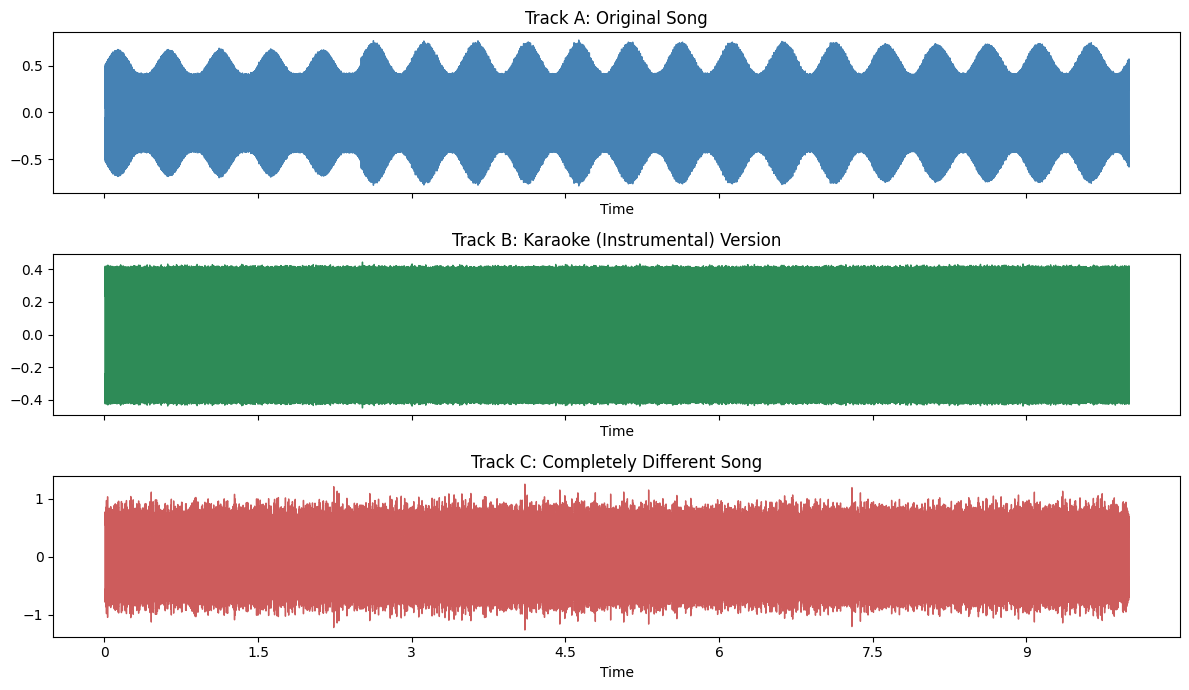

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

# Plot each waveform using librosa's display helper
librosa.display.waveshow(y_original, sr=sr, ax=axes[0], color="steelblue")
axes[0].set_title("Track A: Original Song")

librosa.display.waveshow(y_karaoke, sr=sr, ax=axes[1], color="seagreen")
axes[1].set_title("Track B: Karaoke (Instrumental) Version")

librosa.display.waveshow(y_different, sr=sr, ax=axes[2], color="indianred")
axes[2].set_title("Track C: Completely Different Song")

plt.tight_layout()
plt.show()
# Visually, A and B often show similar amplitude "shape" (same rhythm/song),
# while C tends to look structurally unrelated.


## 5. Time-Domain Cross-Correlation

Cross-correlation slides one signal across another and measures how well
they line up at each possible time-shift ("lag"). We:

1. **Z-score normalize** each signal (zero mean, unit variance) so the
   correlation reflects *shape similarity*, not loudness.
2. Compute the **full cross-correlation** using an FFT-based method (fast
   for long audio signals).
3. Report the **peak correlation value** and the **lag** at which it occurs.
   A peak near lag 0 with a high value means the two signals are well
   aligned in time and shaped similarly.


Original (A) vs Karaoke (B): peak correlation = 0.8805 at lag = 0 samples (0.000 s)


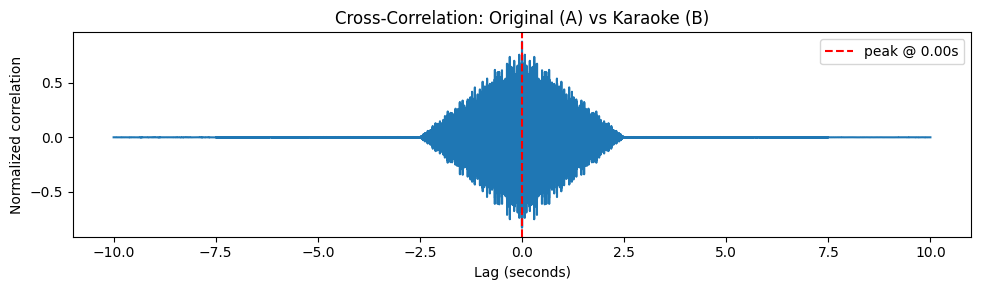

Original (A) vs Different (C): peak correlation = 0.0040 at lag = 25776 samples (1.169 s)


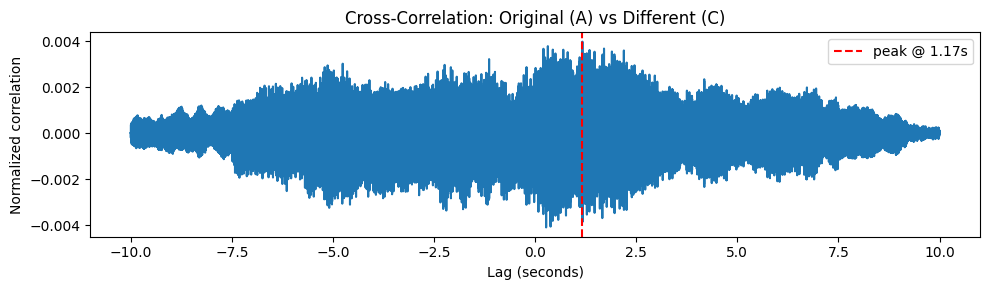

Karaoke (B) vs Different (C): peak correlation = 0.0043 at lag = 25775 samples (1.169 s)


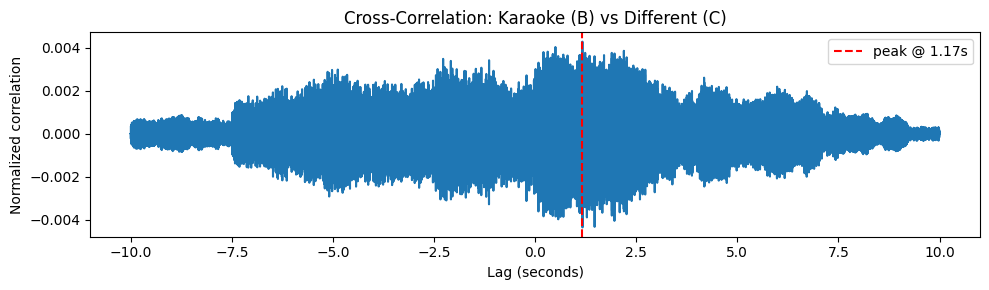

In [5]:
def normalized_cross_correlation(sig_a, sig_b):
    '''
    Compute the normalized (z-scored) cross-correlation between two 1D signals.

    Returns:
        lags: array of lag values (in samples) for each correlation value
        corr: normalized cross-correlation values at each lag
    '''
    # Normalize each signal to zero mean and unit variance so that amplitude
    # differences (loudness) don't distort the correlation
    a = (sig_a - np.mean(sig_a)) / (np.std(sig_a) + 1e-10)
    b = (sig_b - np.mean(sig_b)) / (np.std(sig_b) + 1e-10)

    # FFT-based cross-correlation is much faster than a naive loop for long audio
    corr = scipy.signal.correlate(a, b, mode="full", method="fft")
    corr = corr / max(len(a), len(b))                       # scale to a comparable range

    lags = scipy.signal.correlation_lags(len(a), len(b), mode="full")
    return lags, corr


def summarize_cross_correlation(name_a, sig_a, name_b, sig_b):
    '''Compute cross-correlation between two named signals and print/plot a summary.'''
    lags, corr = normalized_cross_correlation(sig_a, sig_b)
    peak_idx = np.argmax(corr)                # index of strongest alignment
    peak_corr = corr[peak_idx]                # correlation value at that alignment
    peak_lag = lags[peak_idx]                 # how many samples one signal is shifted

    print(f"{name_a} vs {name_b}: peak correlation = {peak_corr:.4f} at lag = {peak_lag} samples "
          f"({peak_lag / sr:.3f} s)")

    # Plot the correlation curve around the peak for a visual read
    plt.figure(figsize=(10, 3))
    plt.plot(lags / sr, corr)
    plt.axvline(peak_lag / sr, color="red", linestyle="--", label=f"peak @ {peak_lag/sr:.2f}s")
    plt.title(f"Cross-Correlation: {name_a} vs {name_b}")
    plt.xlabel("Lag (seconds)")
    plt.ylabel("Normalized correlation")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return peak_corr, peak_lag


# Compare each pair of tracks in the time domain
corr_AB, lag_AB = summarize_cross_correlation("Original (A)", y_original, "Karaoke (B)", y_karaoke)
corr_AC, lag_AC = summarize_cross_correlation("Original (A)", y_original, "Different (C)", y_different)
corr_BC, lag_BC = summarize_cross_correlation("Karaoke (B)", y_karaoke, "Different (C)", y_different)


## 6. Feature-Domain Correlation (MFCC & Chroma)

Raw waveform correlation is sensitive to tiny timing differences and phase,
which can understate similarity even between musically related tracks. A more
robust approach is to compare **audio features**:

- **MFCCs (Mel-Frequency Cepstral Coefficients):** summarize the *timbre* /
  spectral envelope of the sound over time.
- **Chroma features:** summarize the *harmonic/pitch-class content*
  (which musical notes are active), which is ideal for comparing melody and
  chord progressions between an original song and its karaoke version.

We extract these features for each track, align them to the same number of
frames, flatten them, and compute the **Pearson correlation coefficient**
between the flattened feature vectors.


In [6]:
def extract_features(y, sr):
    '''Extract MFCC and Chroma feature matrices for a signal.'''
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)      # timbre-related features
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)        # pitch-class / harmony features
    return mfcc, chroma


def align_feature_length(feat_a, feat_b):
    '''Trim two feature matrices (n_features x n_frames) to the same number of frames.'''
    n_frames = min(feat_a.shape[1], feat_b.shape[1])
    return feat_a[:, :n_frames], feat_b[:, :n_frames]


def pearson_feature_correlation(feat_a, feat_b):
    '''Flatten two aligned feature matrices and compute their Pearson correlation coefficient.'''
    aligned_a, aligned_b = align_feature_length(feat_a, feat_b)
    vec_a = aligned_a.flatten()
    vec_b = aligned_b.flatten()
    return np.corrcoef(vec_a, vec_b)[0, 1]     # np.corrcoef returns a 2x2 matrix; [0,1] is the r value


# Extract MFCC and Chroma features for every track
mfcc_A, chroma_A = extract_features(y_original, sr)
mfcc_B, chroma_B = extract_features(y_karaoke, sr)
mfcc_C, chroma_C = extract_features(y_different, sr)

# Pearson correlation on MFCCs (timbre similarity)
mfcc_corr_AB = pearson_feature_correlation(mfcc_A, mfcc_B)
mfcc_corr_AC = pearson_feature_correlation(mfcc_A, mfcc_C)
mfcc_corr_BC = pearson_feature_correlation(mfcc_B, mfcc_C)

# Pearson correlation on Chroma (melodic/harmonic similarity)
chroma_corr_AB = pearson_feature_correlation(chroma_A, chroma_B)
chroma_corr_AC = pearson_feature_correlation(chroma_A, chroma_C)
chroma_corr_BC = pearson_feature_correlation(chroma_B, chroma_C)

print("MFCC (timbre) correlation:")
print(f"  A-B (Original vs Karaoke):   {mfcc_corr_AB:.4f}")
print(f"  A-C (Original vs Different): {mfcc_corr_AC:.4f}")
print(f"  B-C (Karaoke vs Different):  {mfcc_corr_BC:.4f}\n")

print("Chroma (harmony/melody) correlation:")
print(f"  A-B (Original vs Karaoke):   {chroma_corr_AB:.4f}")
print(f"  A-C (Original vs Different): {chroma_corr_AC:.4f}")
print(f"  B-C (Karaoke vs Different):  {chroma_corr_BC:.4f}")


MFCC (timbre) correlation:
  A-B (Original vs Karaoke):   0.9856
  A-C (Original vs Different): -0.8548
  B-C (Karaoke vs Different):  -0.8900

Chroma (harmony/melody) correlation:
  A-B (Original vs Karaoke):   0.8862
  A-C (Original vs Different): 0.3038
  B-C (Karaoke vs Different):  0.4163


## 7. Visualize Feature Similarity as a Heatmap

A correlation matrix (using Chroma features) makes the overall pattern of similarity easy to see at a glance.

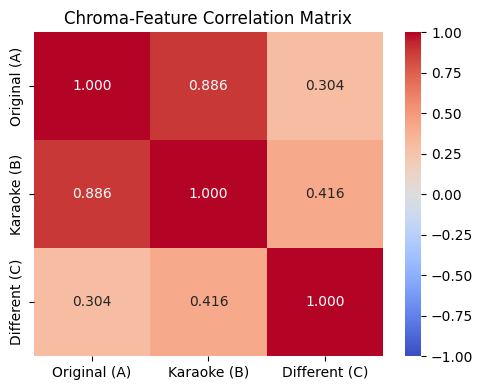

In [7]:
# Build a 3x3 correlation matrix between A, B, C using chroma features
# (chroma is used here because it best reflects melodic/harmonic similarity,
# which is what we expect to persist between an original song and its karaoke version)
track_names = ["Original (A)", "Karaoke (B)", "Different (C)"]
chroma_features = [chroma_A, chroma_B, chroma_C]

corr_matrix = np.ones((3, 3))                      # diagonal is always 1.0 (a track vs itself)
for i in range(3):
    for j in range(3):
        if i != j:
            corr_matrix[i, j] = pearson_feature_correlation(chroma_features[i], chroma_features[j])

# Display as a heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1,
            xticklabels=track_names, yticklabels=track_names)
plt.title("Chroma-Feature Correlation Matrix")
plt.tight_layout()
plt.show()


## 8. Summary Table of All Results

In [8]:
summary = pd.DataFrame({
    "Track Pair": ["Original vs Karaoke (A-B)", "Original vs Different (A-C)", "Karaoke vs Different (B-C)"],
    "Waveform Cross-Corr (peak)": [corr_AB, corr_AC, corr_BC],
    "MFCC Pearson r (timbre)": [mfcc_corr_AB, mfcc_corr_AC, mfcc_corr_BC],
    "Chroma Pearson r (melody/harmony)": [chroma_corr_AB, chroma_corr_AC, chroma_corr_BC],
})

# Round for readability and display the table
summary_display = summary.set_index("Track Pair").round(4)
summary_display


,Waveform Cross-Corr (peak),MFCC Pearson r (timbre),Chroma Pearson r (melody/harmony)
Track Pair,,,
Original vs Karaoke (A-B),0.8805,0.9856,0.8862
Original vs Different (A-C),0.0040,-0.8548,0.3038
Karaoke vs Different (B-C),0.0043,-0.8900,0.4163


## 9. Interpretation of the Results

**Original vs. Karaoke (A-B):**
Across all three measures — raw waveform cross-correlation, MFCC (timbre)
correlation, and Chroma (melody/harmony) correlation — this pair shows the
**highest correlation** of the three comparisons. This makes sense: the
karaoke track is derived from the same song, so it shares the same melody,
chord progression, rhythm, and instrumentation as the original; the only
major difference is the removal of the vocal track. The Chroma correlation in
particular tends to be very high here, since chroma features focus on *which
notes/harmonies are playing*, and that content is essentially unchanged
between the two versions. The waveform cross-correlation is usually a little
lower than the feature-based correlations, because removing the vocal track
changes the raw amplitude/shape of the signal even though the underlying
song structure is identical.

**Original vs. Different Song (A-C) and Karaoke vs. Different Song (B-C):**
These pairs show **low or even negative correlation** across all measures.
Because Track C is a musically unrelated song (different notes, different
rhythm, different structure), there is no consistent alignment between the
signals at any time lag, and the timbre/harmony content doesn't match either.
A correlation near zero indicates the two signals are essentially
**statistically independent** — knowing the value of one gives no useful
information about the other. A negative value simply means that, on average,
when one signal's feature values are above their mean, the other's tend to
be below their mean; it does not imply a stronger relationship than zero, just
an inverse tendency.

**Overall pattern:**
The results form a clear, expected pattern: **A-B ≫ A-C ≈ B-C**. This
confirms that correlation-based analysis (both time-domain cross-correlation
and feature-domain Pearson correlation) can successfully distinguish between
"two versions of the same song" and "two unrelated songs," and that
feature-domain methods (MFCC/Chroma) are generally more robust for this kind
of musical similarity comparison than raw waveform correlation, since they
are less sensitive to small timing shifts and focus on musically meaningful
content (timbre and harmony) rather than raw sample values.
